# Palettes Preview

This notebook previews every palette, shows color‑vision deficiency simulations, and demonstrates discrete/continuous scales on plots and maps.

Palettes are organized by category at the repository root (e.g., `bioluminescence/`, `impressionist/`, `cities/`).

In [56]:
required <- c("ggplot2", "colorspace", "maps", "patchwork")
for (pkg in required) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    install.packages(pkg)
  }
}

library(ggplot2)
library(colorspace)
library(patchwork)

In [57]:
source("R/palettes-data.R")
source("R/palettes.R")

palette_names <- list_palettes()

palette_groups <- list(
  impressionist = c("lillies", "palazzo", "wheatfield"),
  cities = c("miami", "santa_barbara"),
  bioluminescence = c("e_berryi", "e_scolopes", "gpo", "ostracod"),
  uncategorized = c("rosysunset")
)

palette_categories <- do.call(
  rbind,
  lapply(names(palette_groups), function(cat) {
    pals <- intersect(palette_groups[[cat]], palette_names)
    data.frame(
      palette = pals,
      category = cat,
      stringsAsFactors = FALSE
    )
  })
)

remaining <- setdiff(palette_names, palette_categories$palette)
if (length(remaining) > 0) {
  palette_categories <- rbind(
    palette_categories,
    data.frame(
      palette = remaining,
      category = "uncategorized",
      stringsAsFactors = FALSE
    )
  )
}

palette_categories$category <- factor(
  palette_categories$category,
  levels = names(palette_groups)
)

palette_categories$palette <- factor(
  palette_categories$palette,
  levels = palette_names
)

palette_names

[1] "lillies"       "palazzo"       "wheatfield"    "miami"        
 [5] "santa_barbara" "e_berryi"      "e_scolopes"    "gpo"          
 [9] "ostracod"      "rosysunset"

In [58]:
plot_tuning <- list(
  discrete = list(
    ncol_cap = 3,
    ncol_for_four = 2,
    panel_width = 6.2,
    width_padding = 2.0,
    panel_height = 4.6,
    height_padding = 2.0
  ),
  continuous = list(
    ncol_cap = 3,
    ncol_for_four = 2,
    panel_width = 6.4,
    width_padding = 2.2,
    panel_height = 5.4,
    height_padding = 2.2
  ),
  map = list(
    ncol_for_four = 2,
    panel_width = 5.2,
    width_padding = 1.8,
    panel_height = 3.8,
    height_padding = 2.0
  )
)
plot_tuning

$discrete
$discrete$ncol_cap
[1] 3

$discrete$ncol_for_four
[1] 2

$discrete$panel_width
[1] 6.2

$discrete$width_padding
[1] 2

$discrete$panel_height
[1] 4.6

$discrete$height_padding
[1] 2


$continuous
$continuous$ncol_cap
[1] 3

$continuous$ncol_for_four
[1] 2

$continuous$panel_width
[1] 6.4

$continuous$width_padding
[1] 2.2

$continuous$panel_height
[1] 5.4

$continuous$height_padding
[1] 2.2


$map
$map$ncol_for_four
[1] 2

$map$panel_width
[1] 5.2

$map$width_padding
[1] 1.8

$map$panel_height
[1] 3.8

$map$height_padding
[1] 2

## All palettes

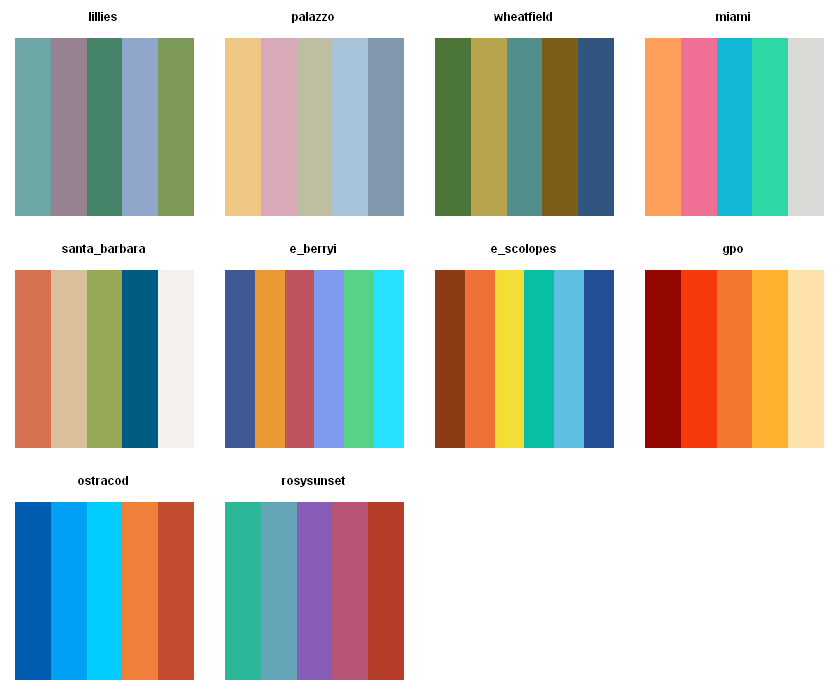

In [59]:
palettes_show(names = palette_names)

## Color‑vision deficiency simulations

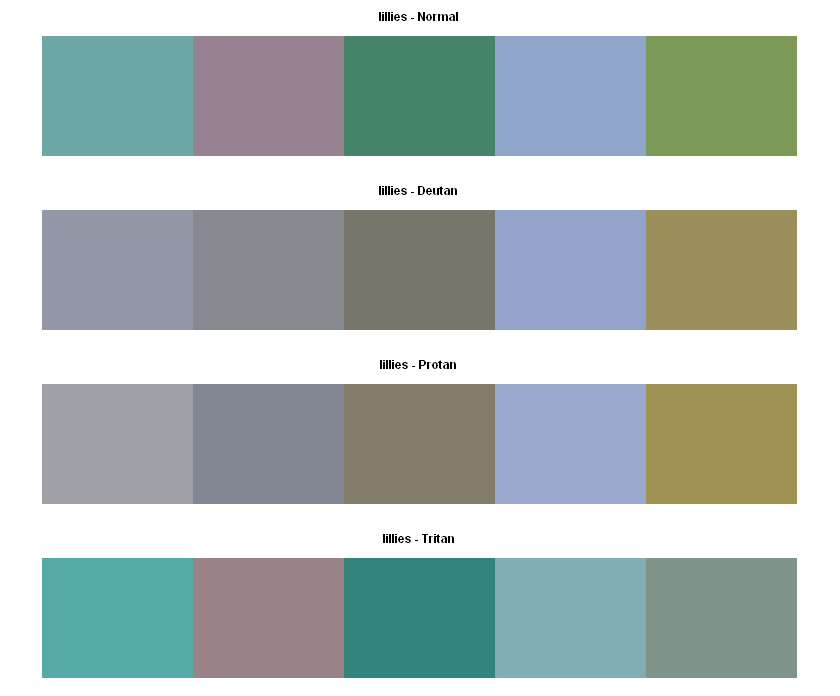

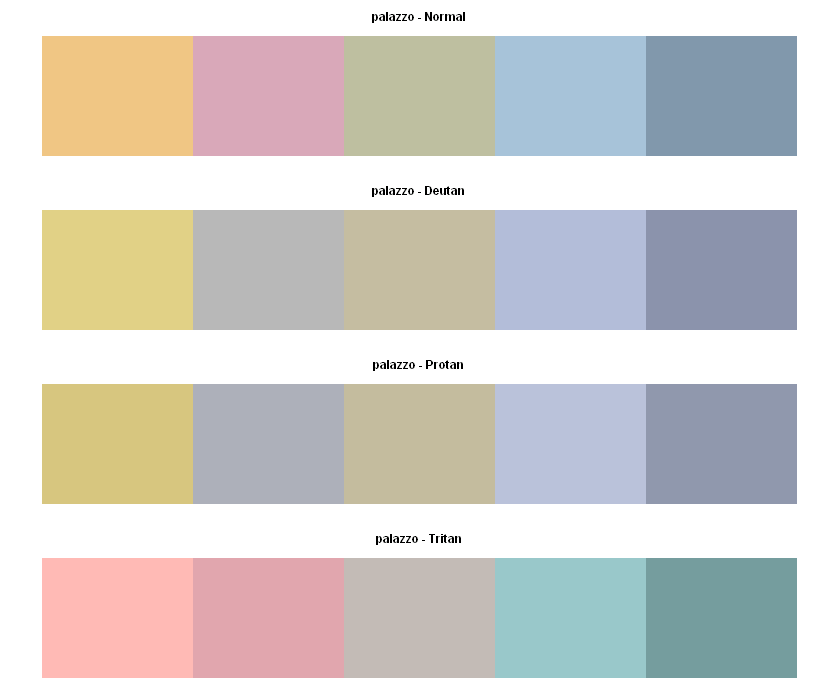

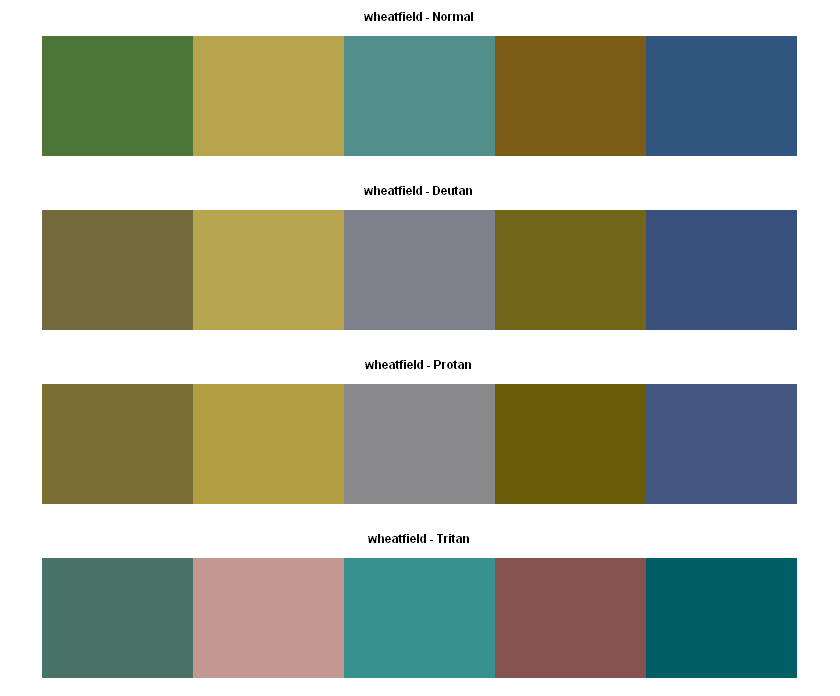

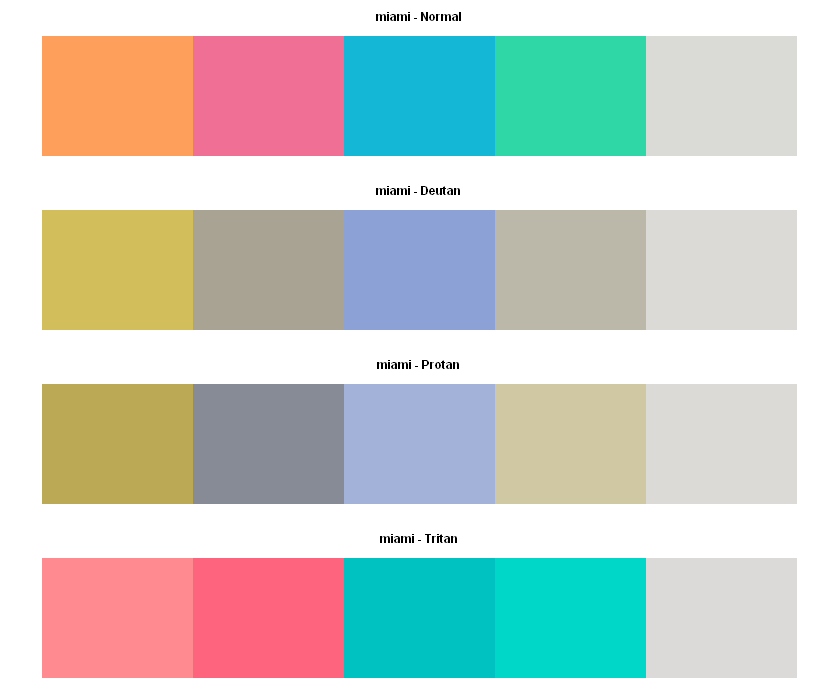

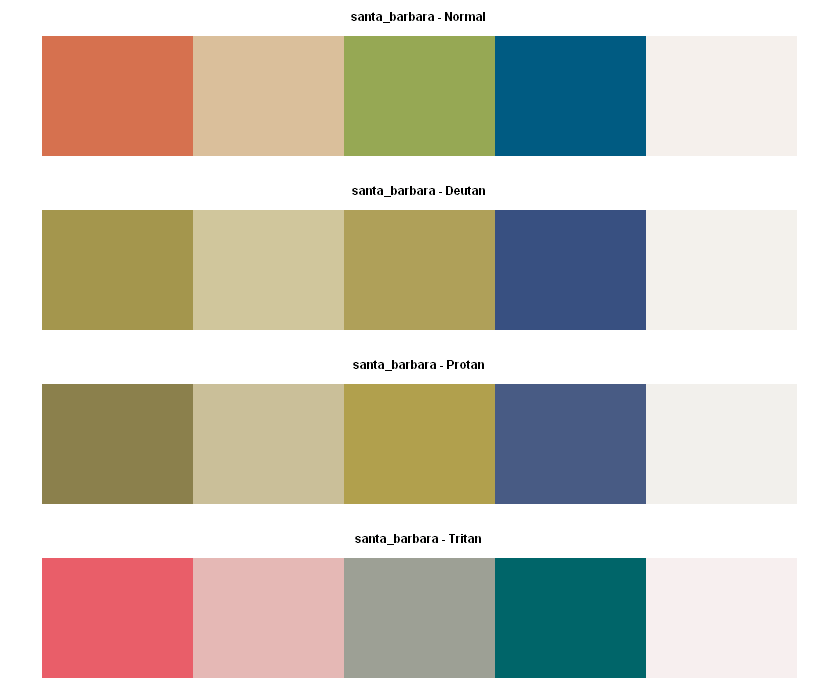

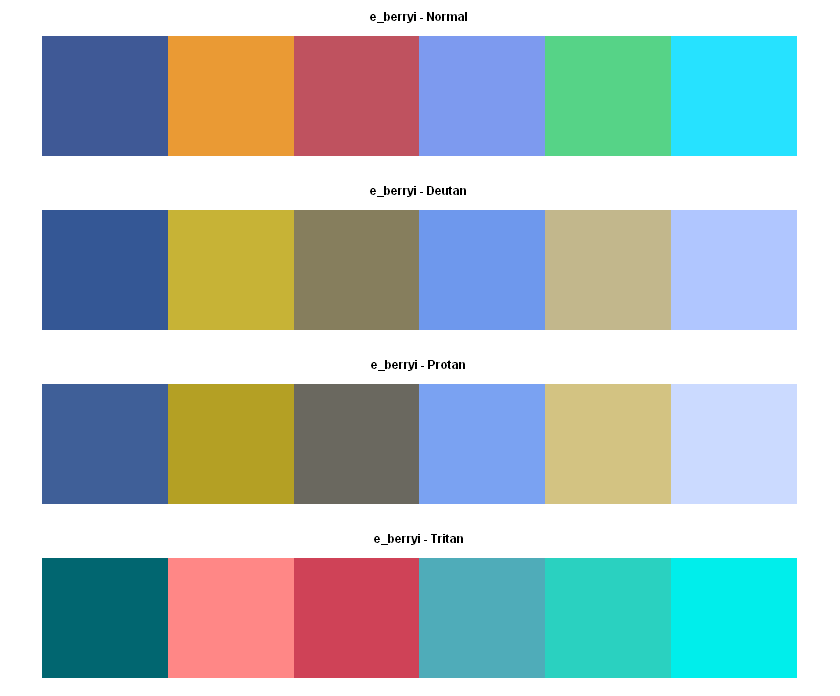

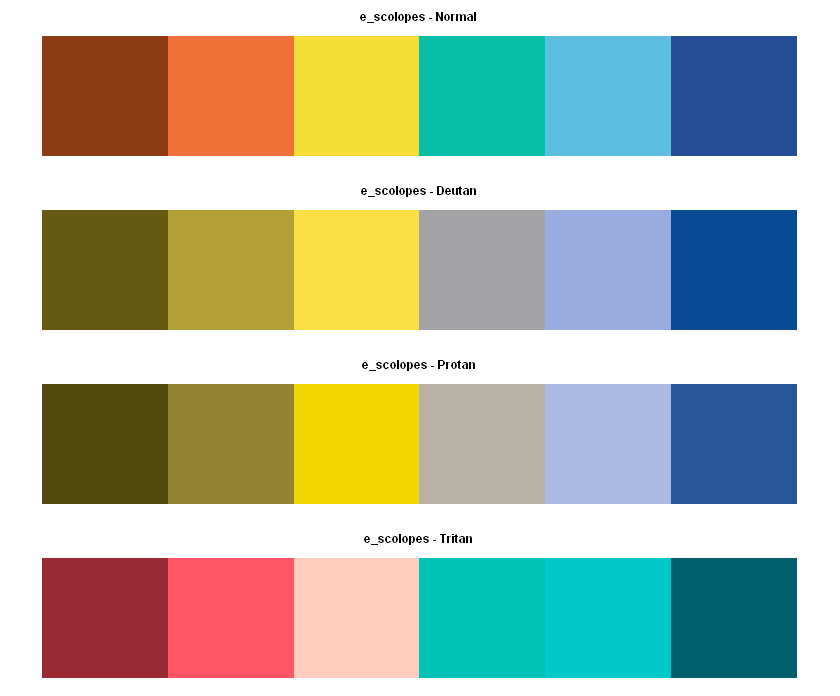

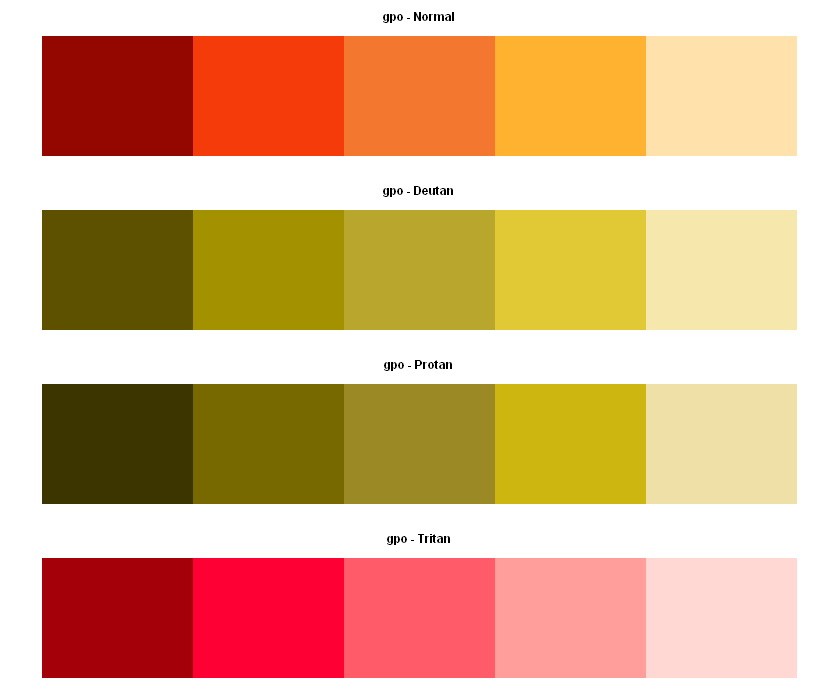

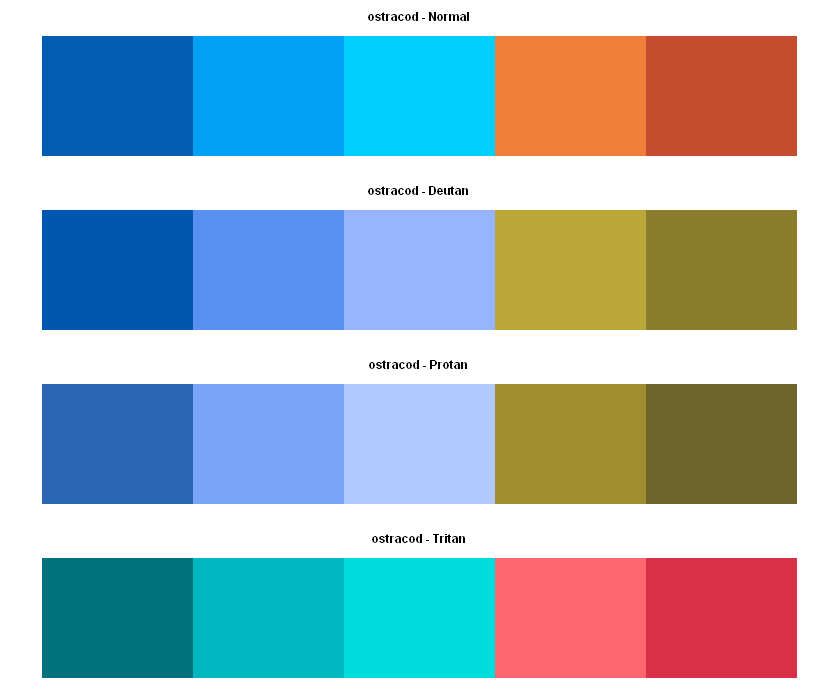

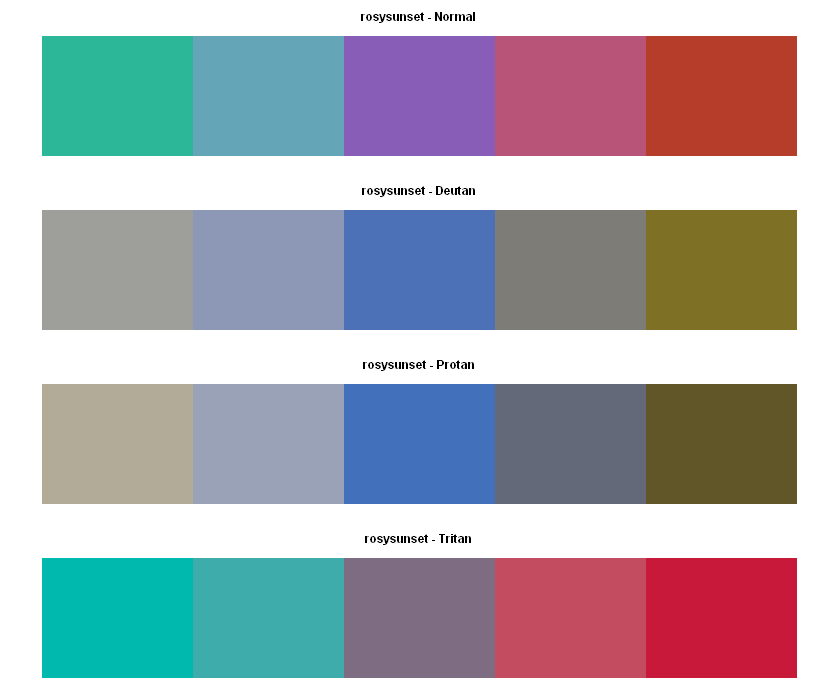

In [60]:
plot_colors <- function(cols, main = NULL) {
  par(mar = c(0.8, 0.8, 2, 0.8))
  plot.new()
  x <- seq(0, 1, length.out = length(cols) + 1)
  for (i in seq_along(cols)) {
    rect(x[i], 0, x[i + 1], 1, col = cols[i], border = NA)
  }
  if (!is.null(main)) title(main, cex.main = 0.9)
}

simulate_cvd_safe <- function(cols, cvd_type) {
  normalize_cvd_output <- function(x) {
    if (is.character(x)) return(x)
    if (is.matrix(x)) return(rgb(x[, 1], x[, 2], x[, 3]))
    if (inherits(x, c("RGB", "sRGB", "polarLUV", "polarLAB"))) return(colorspace::hex(x))
    return(x)
  }

  try_call <- function(expr) {
    out <- try(expr, silent = TRUE)
    if (!inherits(out, "try-error")) return(normalize_cvd_output(out))
    NULL
  }

  fmls <- names(formals(colorspace::simulate_cvd))

  # Try with hex colors first
  if ("type" %in% fmls) {
    res <- try_call(colorspace::simulate_cvd(cols, type = cvd_type))
    if (!is.null(res)) return(res)
  }
  if ("cvd" %in% fmls) {
    res <- try_call(colorspace::simulate_cvd(cols, cvd = cvd_type))
    if (!is.null(res)) return(res)
  }
  res <- try_call(colorspace::simulate_cvd(cols, cvd_type))
  if (!is.null(res)) return(res)

  # Fallback: convert to numeric RGB matrix (0-1)
  rgb_mat <- t(col2rgb(cols)) / 255
  if ("type" %in% fmls) {
    res <- try_call(colorspace::simulate_cvd(rgb_mat, type = cvd_type))
    if (!is.null(res)) return(res)
  }
  if ("cvd" %in% fmls) {
    res <- try_call(colorspace::simulate_cvd(rgb_mat, cvd = cvd_type))
    if (!is.null(res)) return(res)
  }
  res <- try_call(colorspace::simulate_cvd(rgb_mat, cvd_type))
  if (!is.null(res)) return(res)

  # Additional fallback for colorspace versions exposing per-type helpers
  cvd_fun <- switch(
    cvd_type,
    deutan = get0("deutan", asNamespace("colorspace"), inherits = FALSE),
    protan = get0("protan", asNamespace("colorspace"), inherits = FALSE),
    tritan = get0("tritan", asNamespace("colorspace"), inherits = FALSE),
    NULL
  )
  if (is.function(cvd_fun)) {
    res <- try_call(cvd_fun(cols))
    if (!is.null(res)) return(res)
    res <- try_call(cvd_fun(rgb_mat))
    if (!is.null(res)) return(res)
  }

  stop("simulate_cvd failed for this colorspace version.")
}

preview_cvd <- function(palette, n = NULL, type = c("discrete", "continuous")) {
  type <- match.arg(type)
  cols <- get_palette(palette, n = n, type = type)
  validate_palette(cols)

  sims <- list(
    Normal = cols,
    Deutan = simulate_cvd_safe(cols, "deutan"),
    Protan = simulate_cvd_safe(cols, "protan"),
    Tritan = simulate_cvd_safe(cols, "tritan")
  )

  op <- par(no.readonly = TRUE)
  on.exit(par(op), add = TRUE)
  par(mfrow = c(length(sims), 1))
  for (nm in names(sims)) plot_colors(sims[[nm]], paste(palette, "-", nm))
}

# Preview all palettes with CVD simulation
for (pal in palette_names) {
  preview_cvd(pal)
}

## Discrete data example

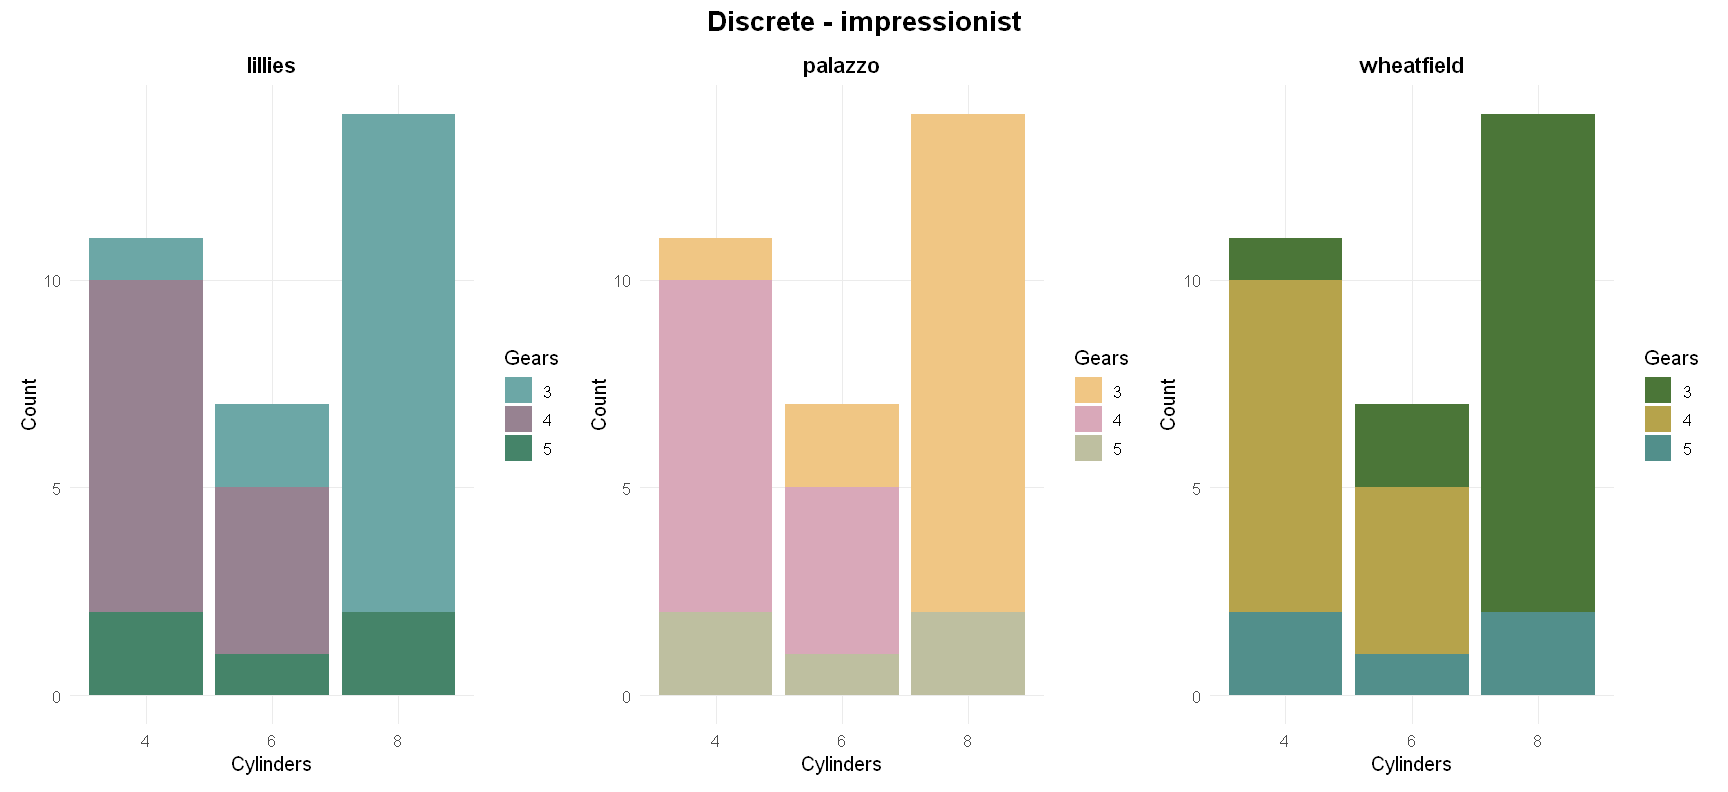

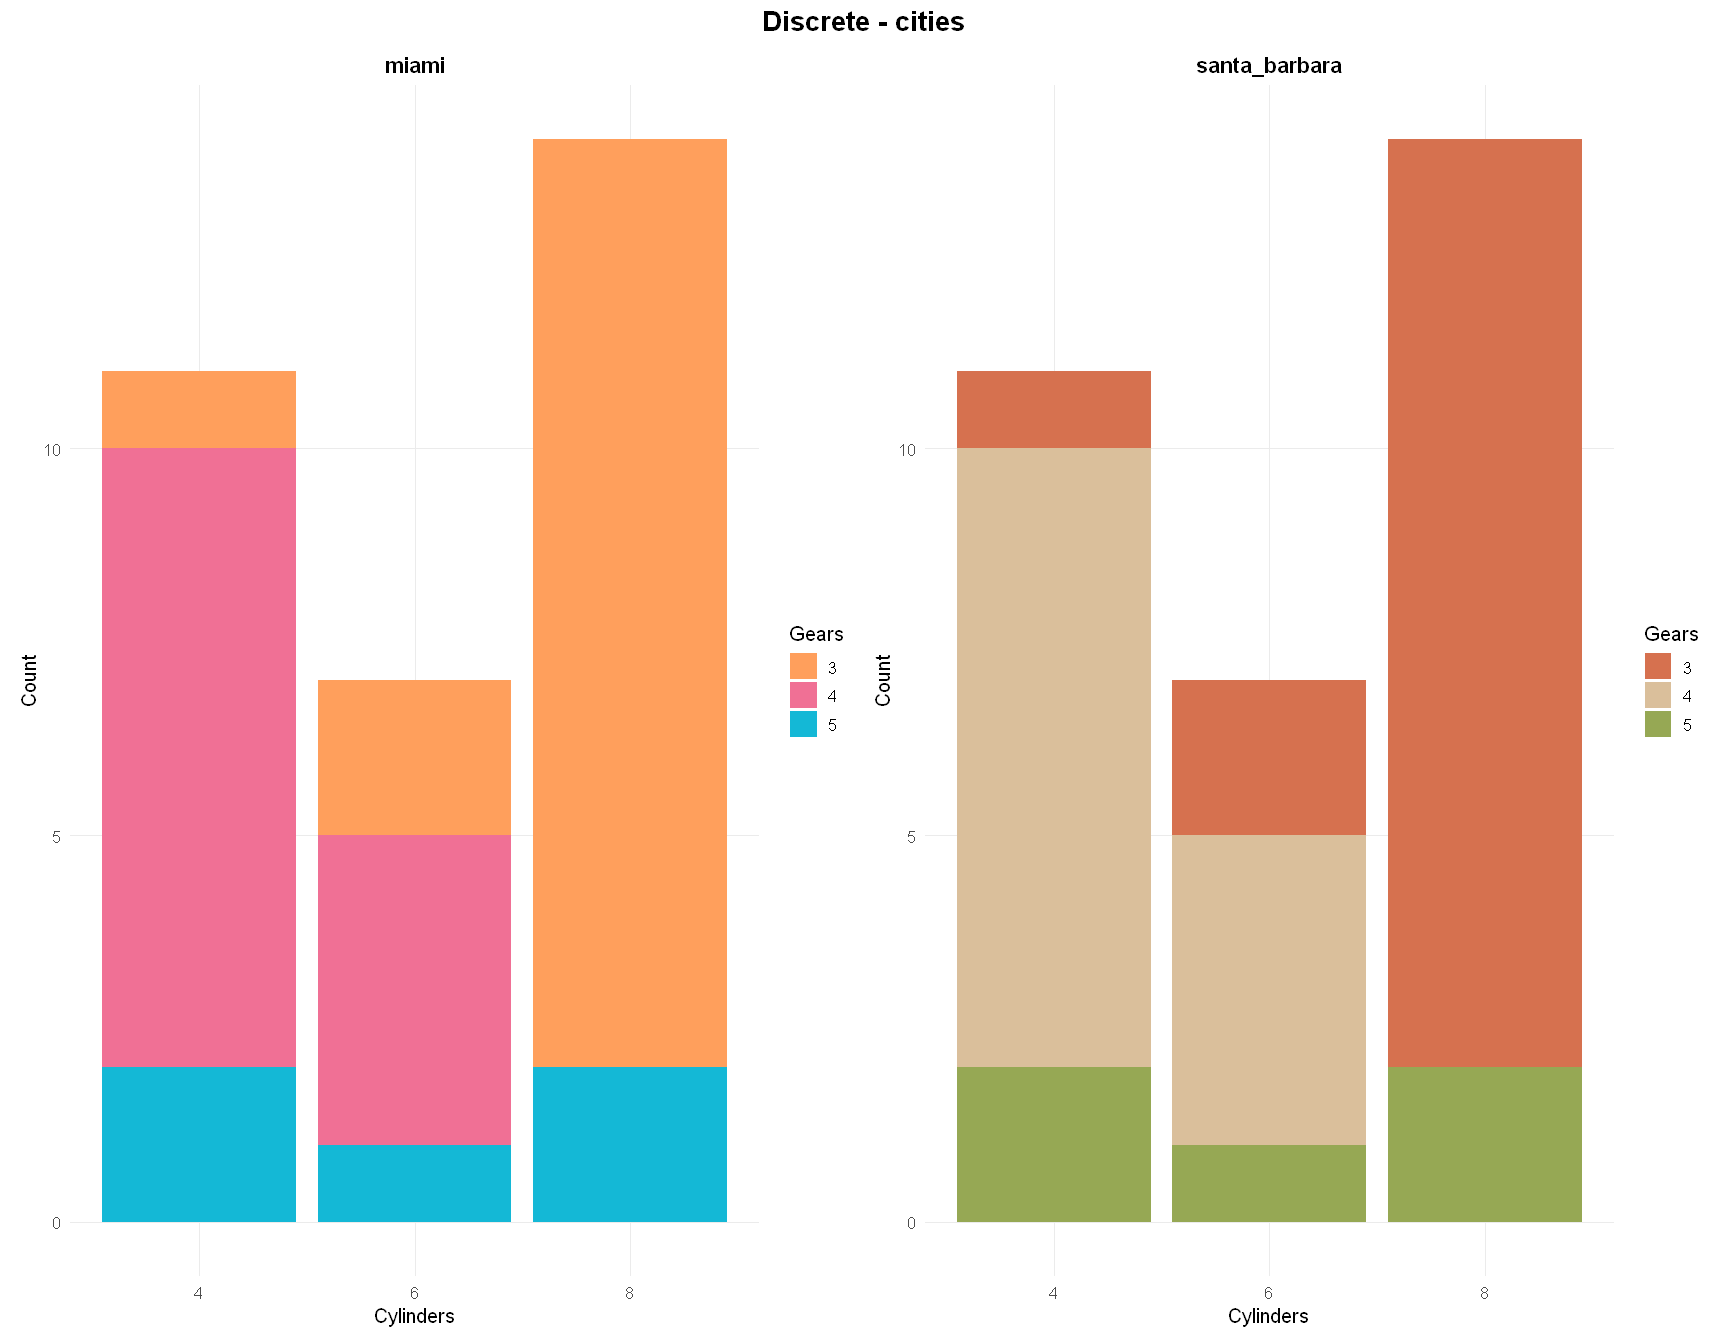

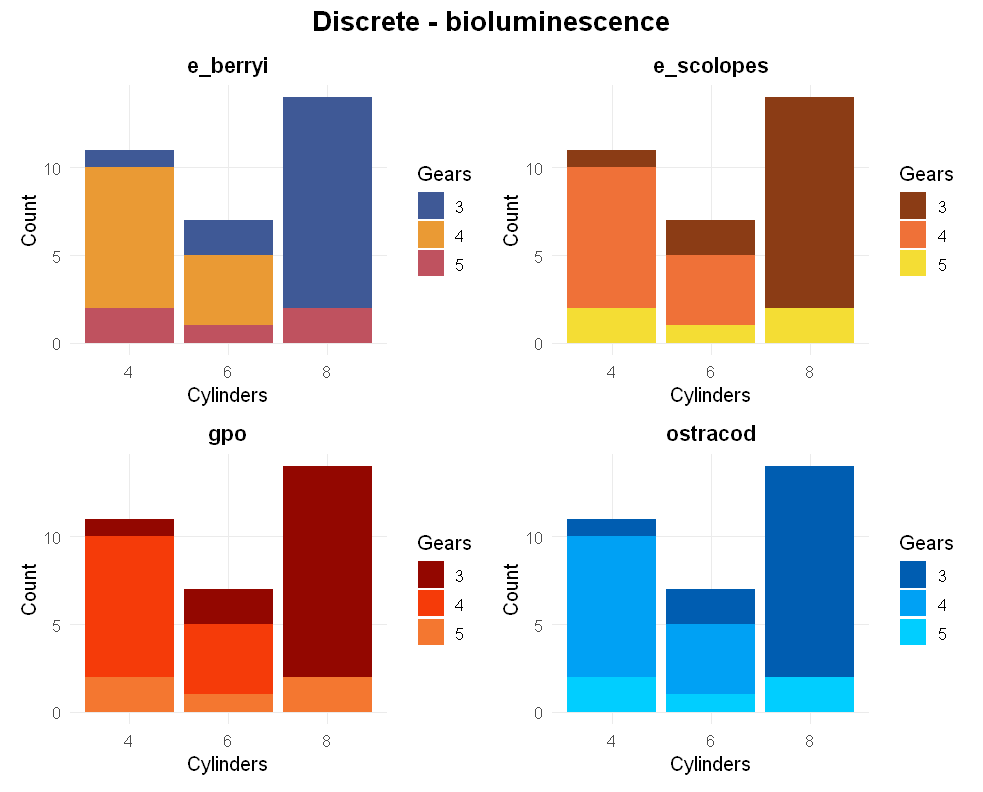

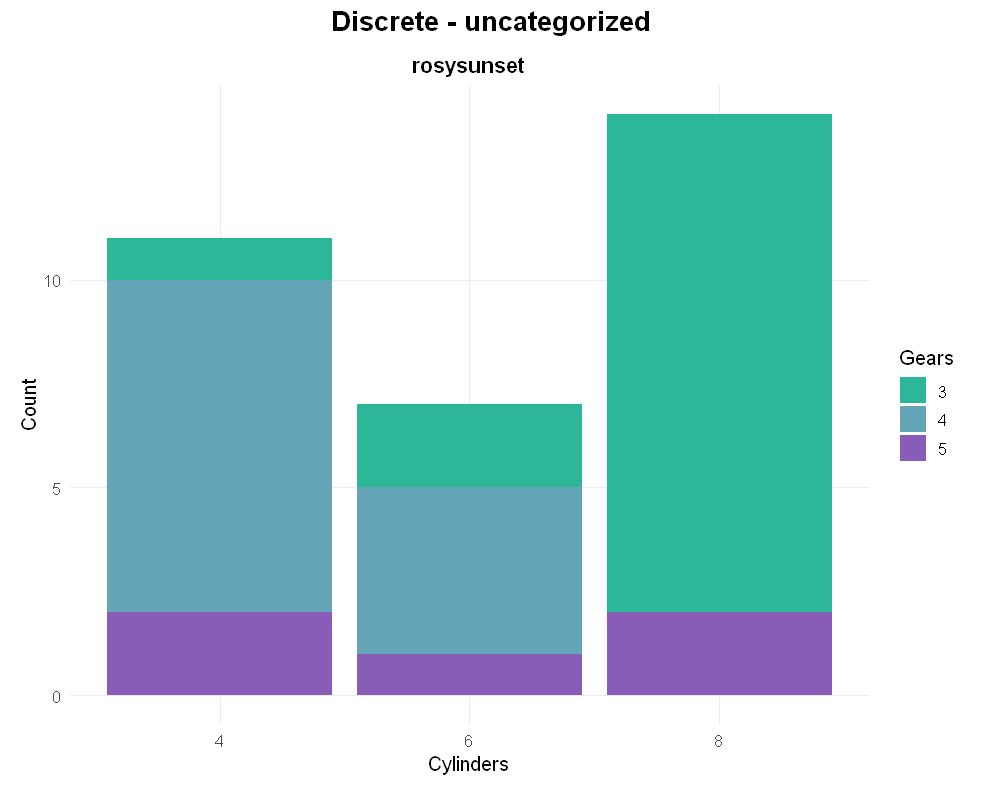

In [61]:
old_repr <- options(repr.plot.width = 10, repr.plot.height = 6)
on.exit(options(old_repr), add = TRUE)

tuning <- plot_tuning$discrete

for (cat in names(palette_groups)) {
  pals <- intersect(palette_groups[[cat]], palette_names)
  if (length(pals) == 0) next

  ncol <- if (length(pals) >= 4) tuning$ncol_for_four else min(tuning$ncol_cap, length(pals))
  nrow <- ceiling(length(pals) / ncol)

  options(
    repr.plot.width = tuning$panel_width * ncol + tuning$width_padding,
    repr.plot.height = tuning$panel_height * nrow + tuning$height_padding
  )

  plots <- lapply(seq_along(pals), function(i) {
    pal <- pals[i]
    ggplot(mtcars, aes(x = factor(cyl), fill = factor(gear))) +
      geom_bar() +
      scale_fill_palettes(pal) +
      labs(title = pal, x = "Cylinders", y = "Count", fill = "Gears") +
      theme_minimal(base_size = 12) +
      theme(
        plot.title = element_text(face = "bold", size = 13, hjust = 0.5),
        panel.grid.minor = element_blank(),
        legend.position = "right"
      )
  })

  print(
    patchwork::wrap_plots(plots, ncol = ncol) +
      patchwork::plot_annotation(
        title = paste("Discrete -", cat),
        theme = theme(plot.title = element_text(face = "bold", size = 16, hjust = 0.5))
      )
  )
}

## Continuous data example

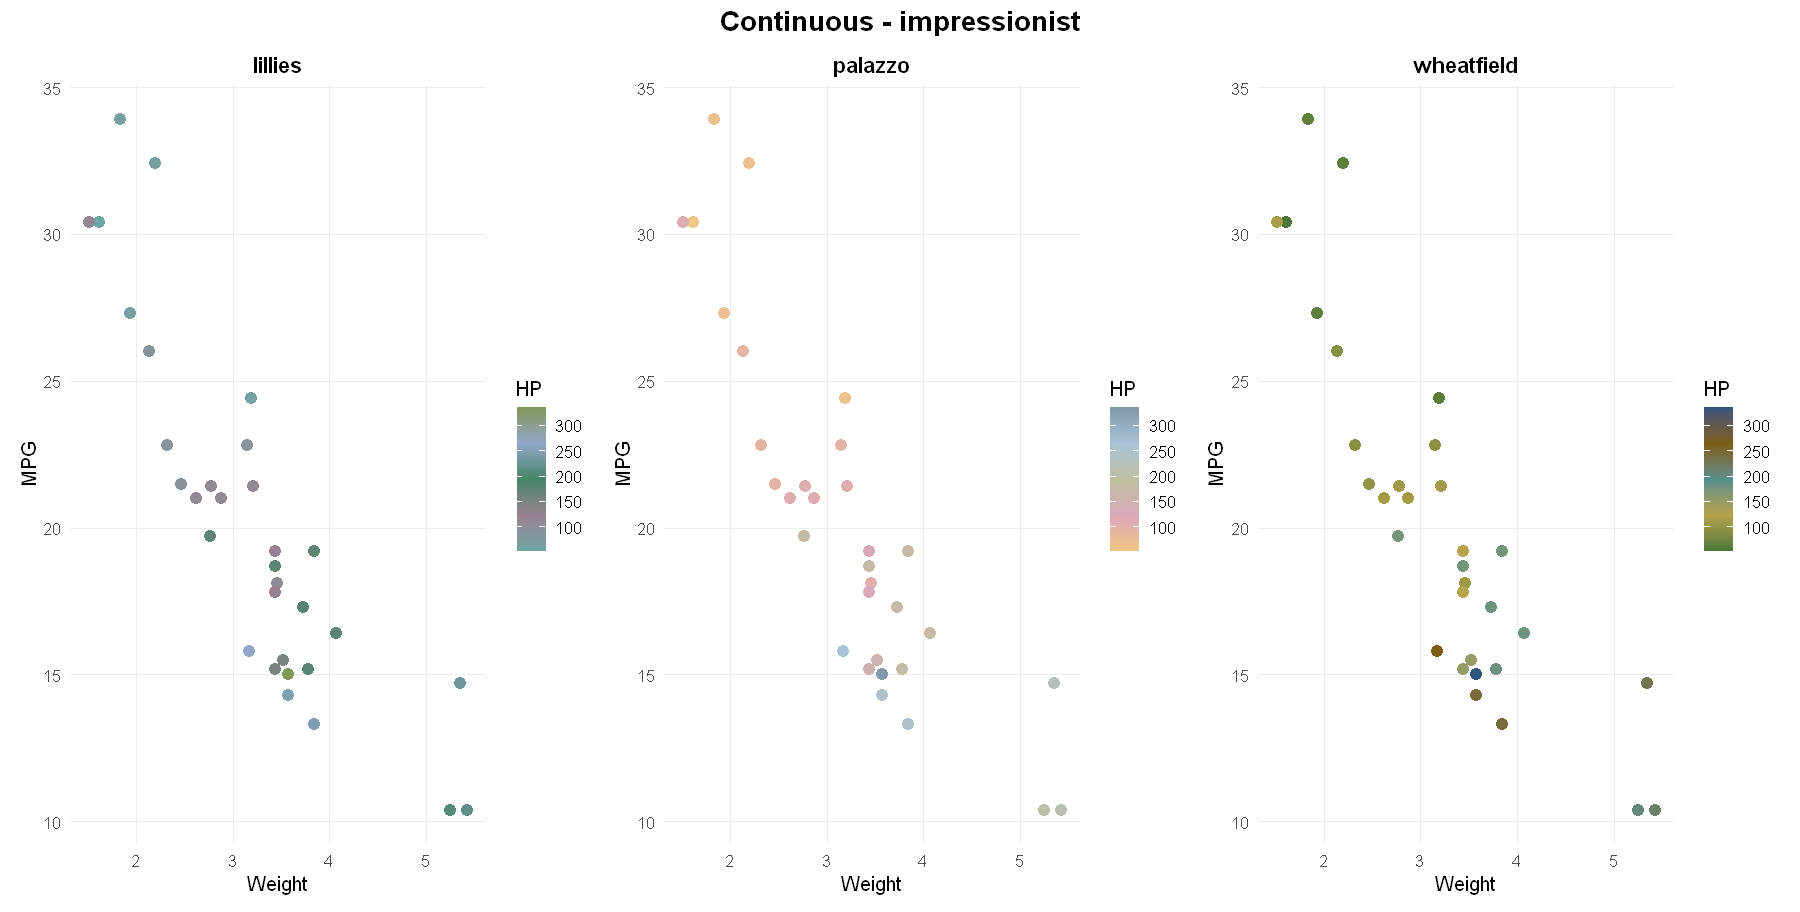

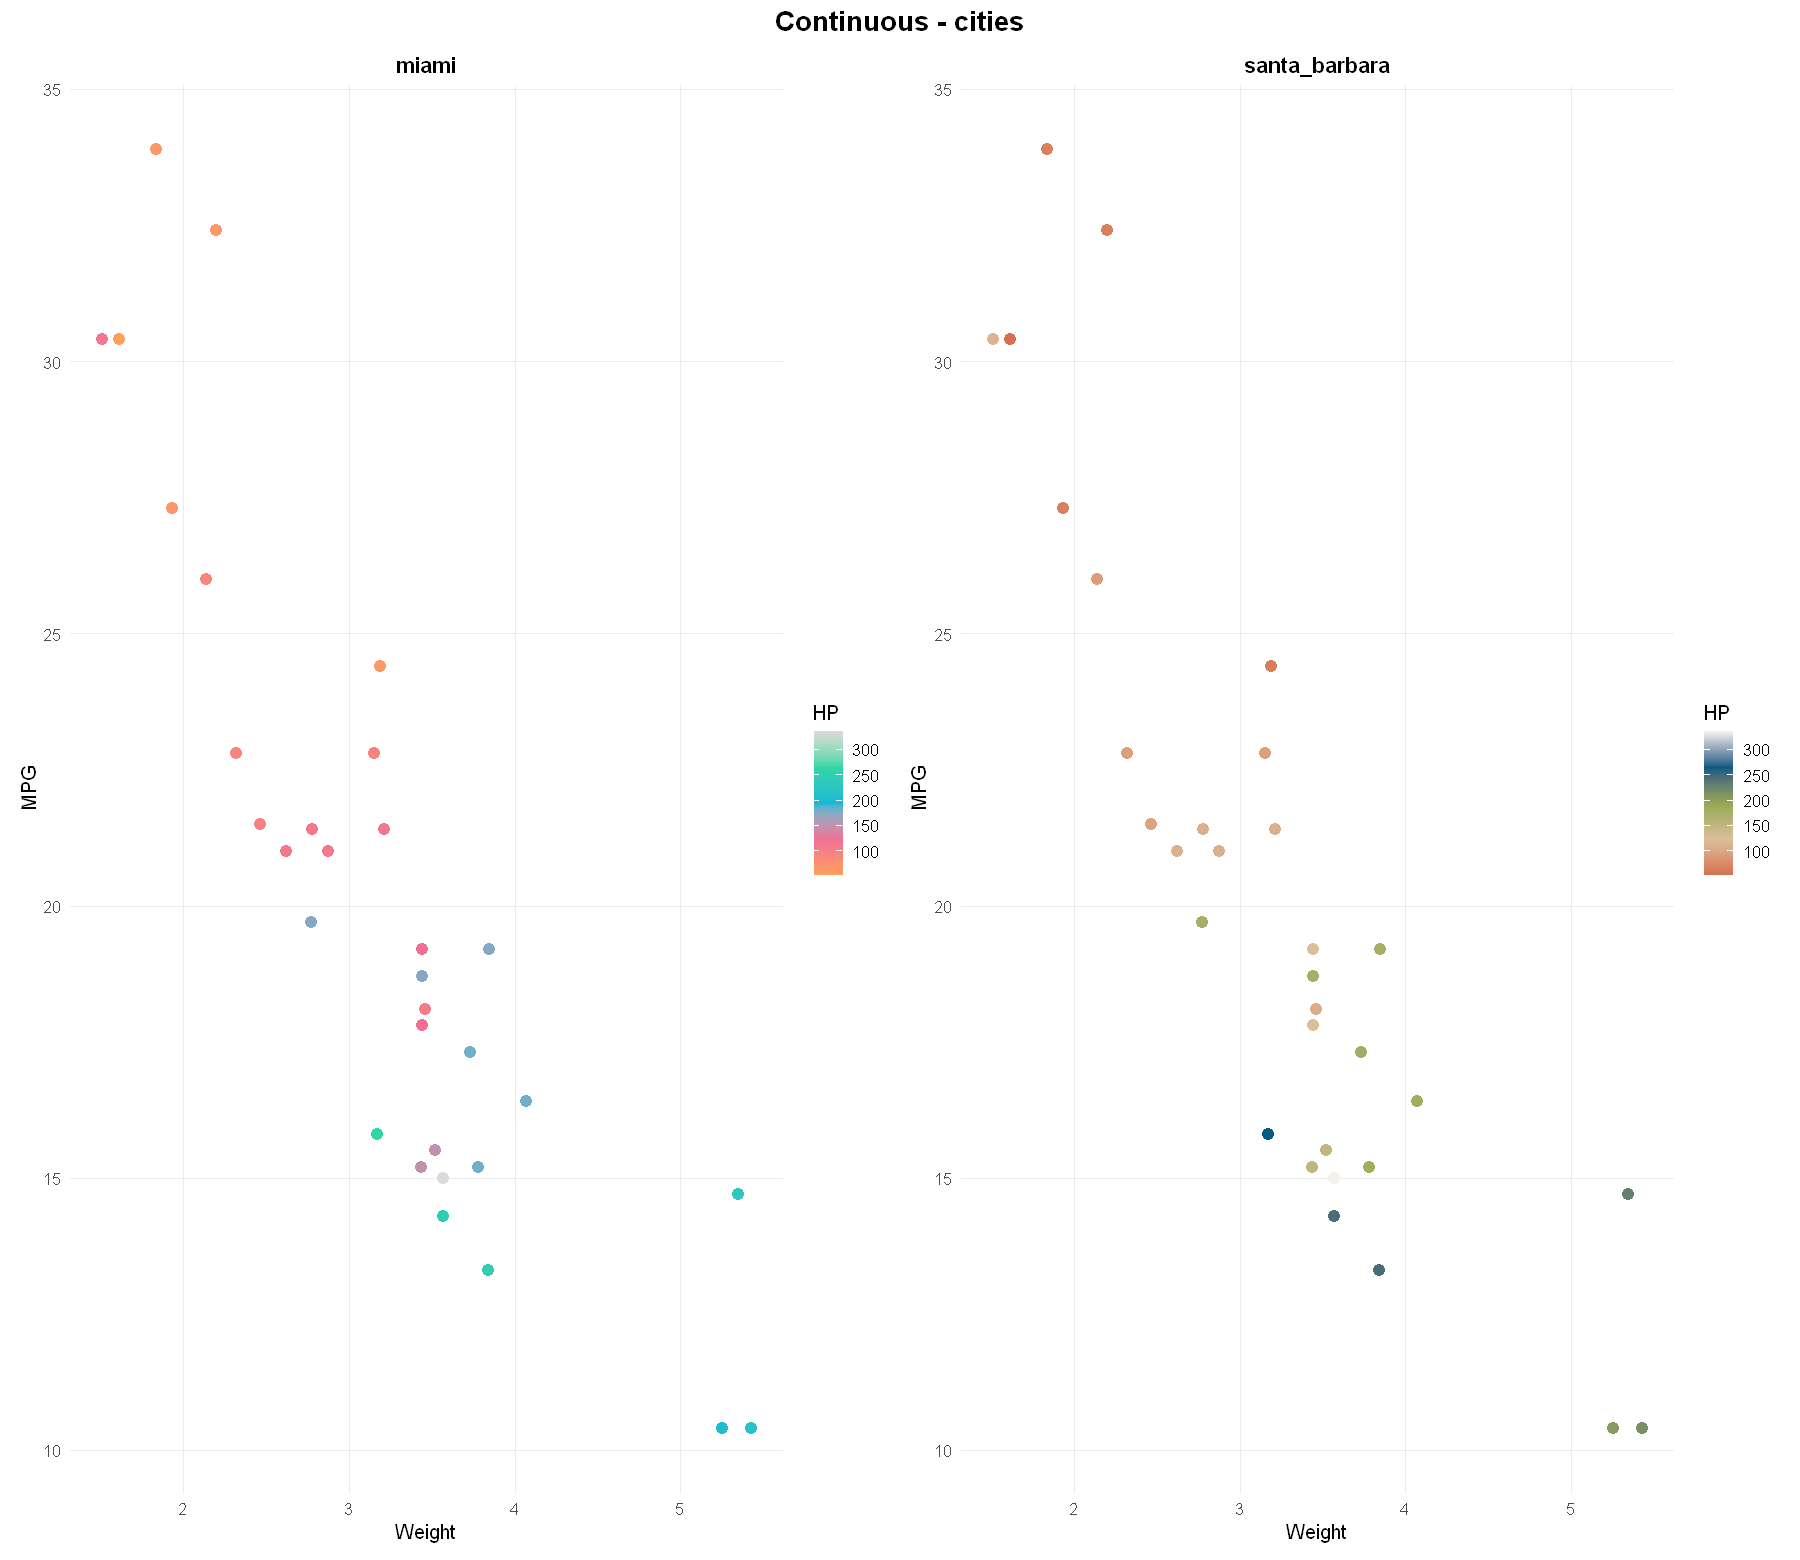

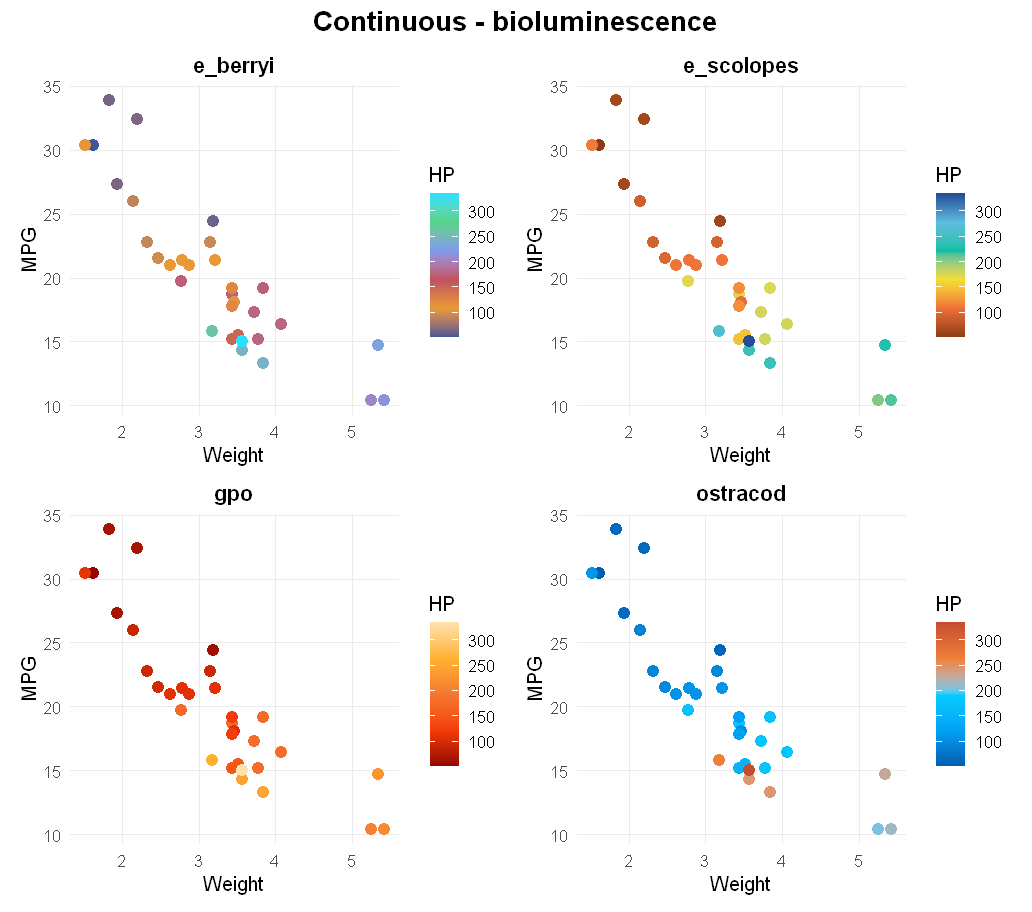

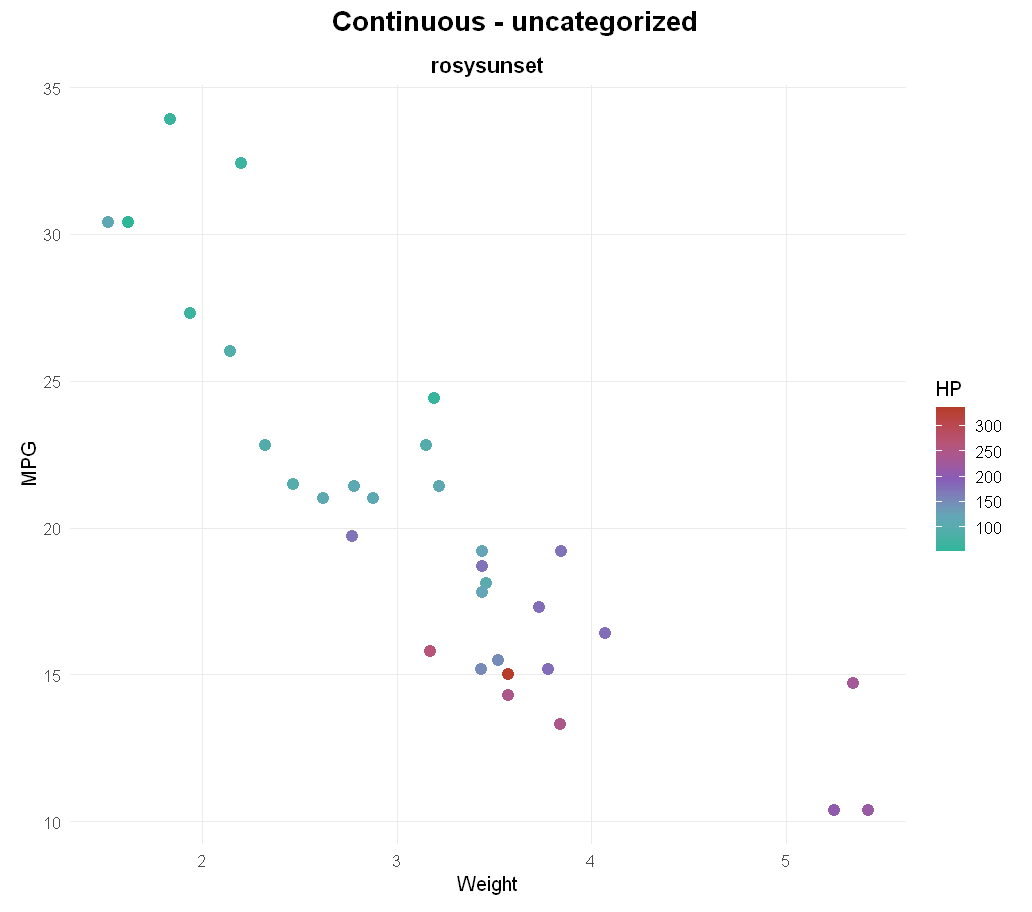

In [62]:
old_repr <- options(repr.plot.width = 10, repr.plot.height = 6)
on.exit(options(old_repr), add = TRUE)

tuning <- plot_tuning$continuous

for (cat in names(palette_groups)) {
  pals <- intersect(palette_groups[[cat]], palette_names)
  if (length(pals) == 0) next

  ncol <- if (length(pals) >= 4) tuning$ncol_for_four else min(tuning$ncol_cap, length(pals))
  nrow <- ceiling(length(pals) / ncol)

  options(
    repr.plot.width = tuning$panel_width * ncol + tuning$width_padding,
    repr.plot.height = tuning$panel_height * nrow + tuning$height_padding
  )

  plots <- lapply(seq_along(pals), function(i) {
    pal <- pals[i]
    ggplot(mtcars, aes(x = wt, y = mpg, color = hp)) +
      geom_point(size = 3) +
      scale_color_palettes_continuous(pal) +
      labs(title = pal, x = "Weight", y = "MPG", color = "HP") +
      theme_minimal(base_size = 12) +
      theme(
        plot.title = element_text(face = "bold", size = 13, hjust = 0.5),
        panel.grid.minor = element_blank(),
        legend.position = "right"
      )
  })

  print(
    patchwork::wrap_plots(plots, ncol = ncol) +
      patchwork::plot_annotation(
        title = paste("Continuous -", cat),
        theme = theme(plot.title = element_text(face = "bold", size = 16, hjust = 0.5))
      )
  )
}

## Map example

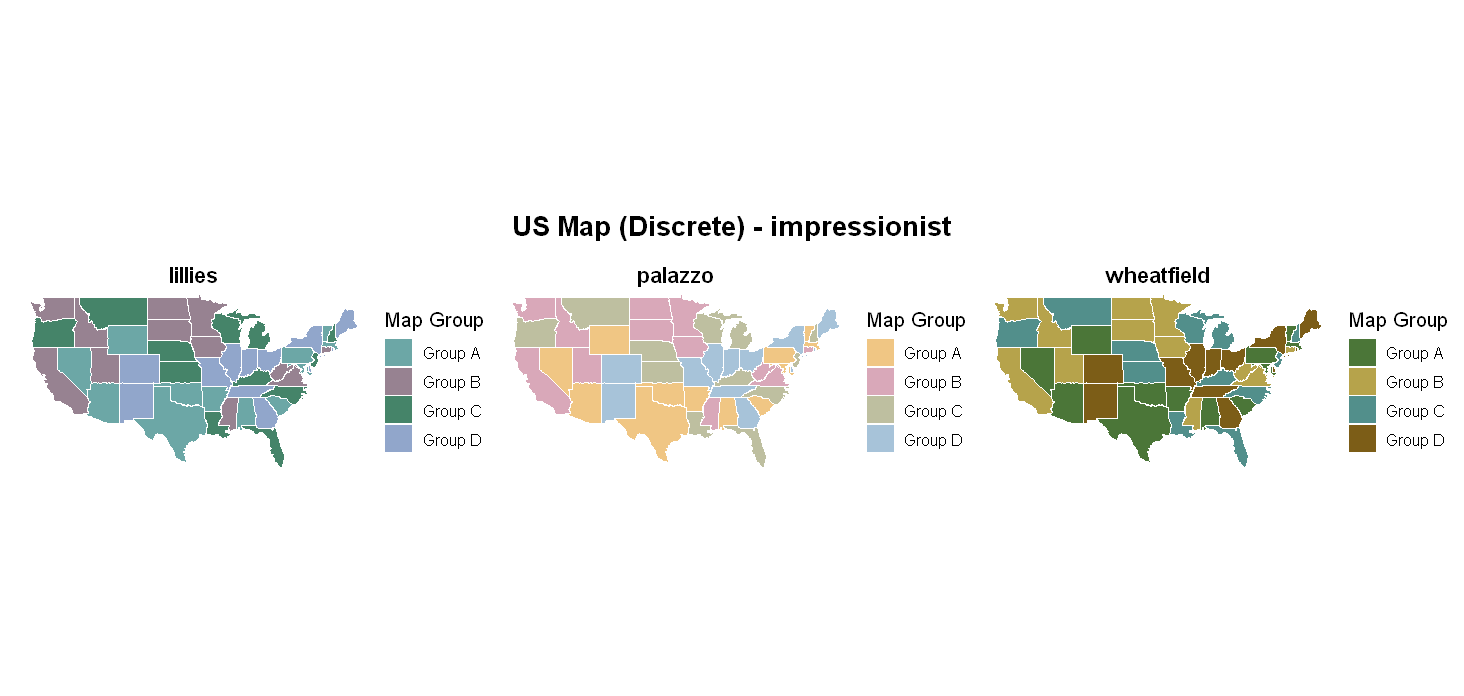

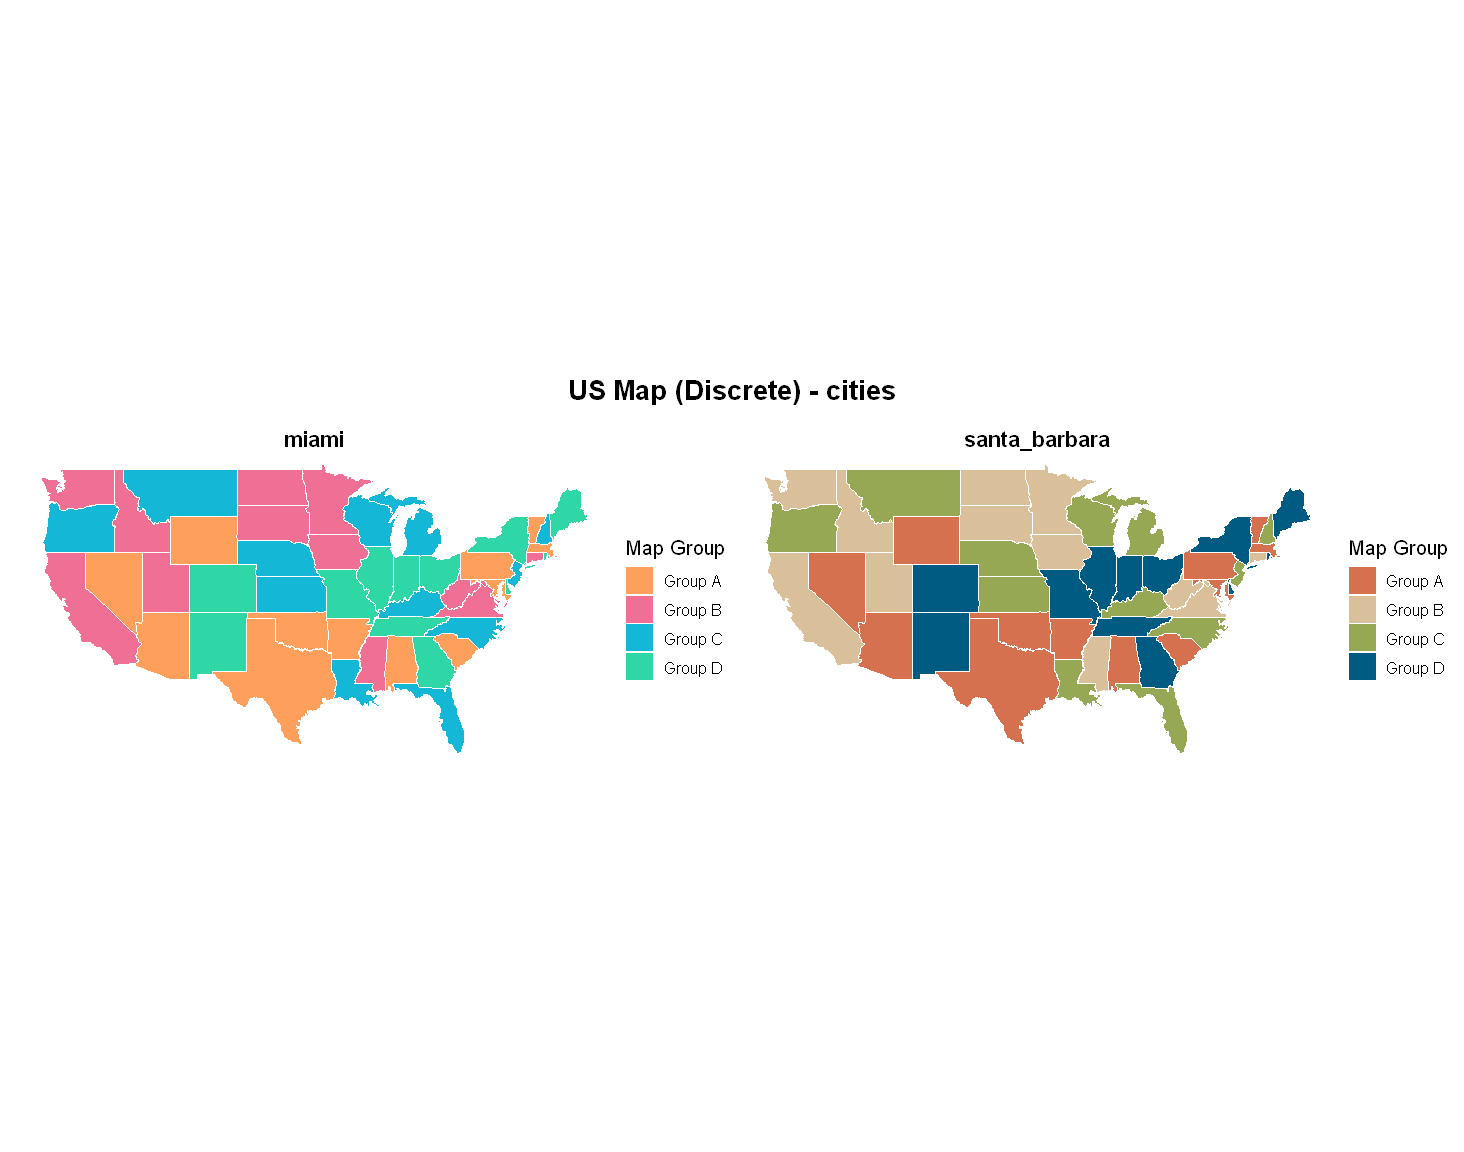

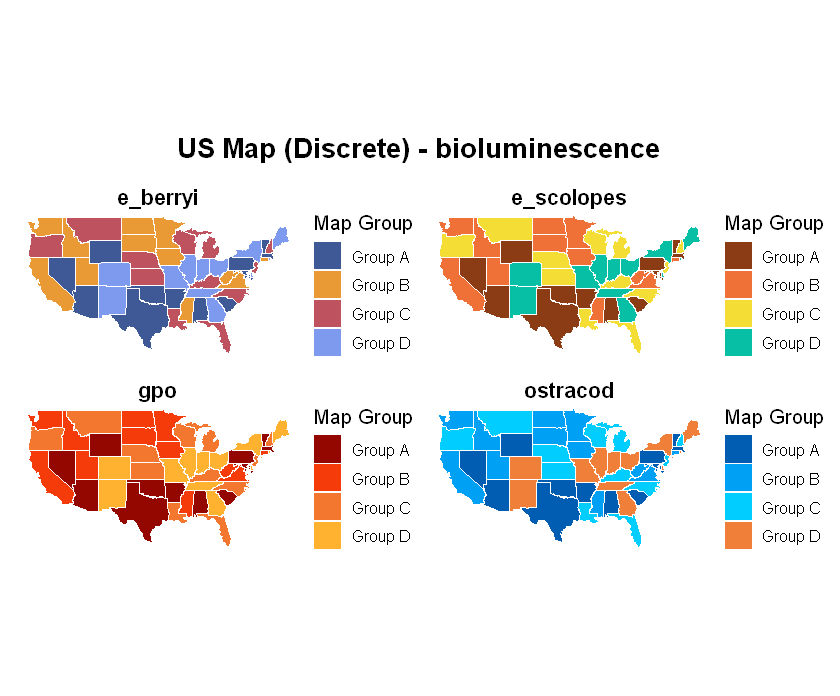

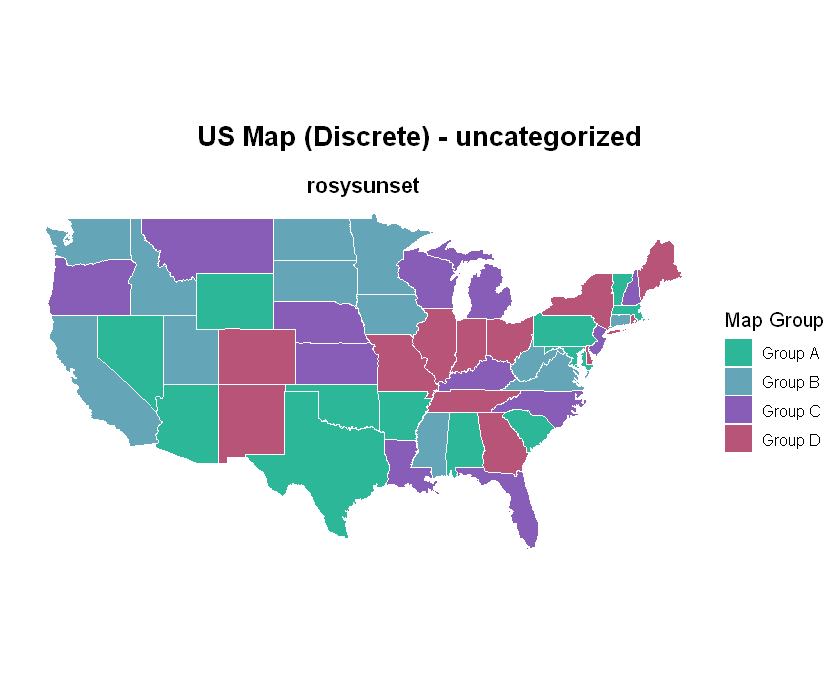

In [63]:
us_states <- ggplot2::map_data("state")
contiguous_states <- setdiff(tolower(state.name), c("alaska", "hawaii"))
us_states <- subset(us_states, region %in% contiguous_states)

set.seed(42)
state_groups <- data.frame(
  region = sort(unique(us_states$region)),
  map_group = sample(rep(c("Group A", "Group B", "Group C", "Group D"), length.out = length(unique(us_states$region)))),
  stringsAsFactors = FALSE
)
state_groups$map_group <- factor(state_groups$map_group, levels = c("Group A", "Group B", "Group C", "Group D"))

us_states2 <- merge(us_states, state_groups, by = "region", all.x = TRUE)

old_repr <- options(repr.plot.width = 12, repr.plot.height = 6)
on.exit(options(old_repr), add = TRUE)

tuning <- plot_tuning$map

for (cat in names(palette_groups)) {
  pals <- intersect(palette_groups[[cat]], palette_names)
  if (length(pals) == 0) next

  ncol <- if (length(pals) >= 4) tuning$ncol_for_four else length(pals)
  nrow <- ceiling(length(pals) / ncol)

  options(
    repr.plot.width = tuning$panel_width * ncol + tuning$width_padding,
    repr.plot.height = tuning$panel_height * nrow + tuning$height_padding
  )

  plots <- lapply(seq_along(pals), function(i) {
    pal <- pals[i]
    ggplot(us_states2, aes(long, lat, group = group, fill = map_group)) +
      geom_polygon(color = "white", linewidth = 0.15) +
      coord_quickmap() +
      scale_fill_palettes(pal) +
      labs(title = pal, fill = "Map Group") +
      theme_void(base_size = 12) +
      theme(
        plot.title = element_text(face = "bold", size = 13, hjust = 0.5),
        legend.position = "right",
        plot.margin = margin(3, 3, 3, 3)
      )
  })

  print(
    patchwork::wrap_plots(plots, ncol = ncol) +
      patchwork::plot_annotation(
        title = paste("US Map (Discrete) -", cat),
        theme = theme(plot.title = element_text(face = "bold", size = 16, hjust = 0.5))
      )
  )
}